# scRNA-seq Cell Type Classification: 3k PBMC Dataset
**Author:** Dana Harper  
**Dataset:** 10x Genomics 3k PBMCs from a Healthy Donor  
**Tools:** Scanpy, scikit-learn, Python  

## Overview
This notebook implements a full single-cell RNA sequencing analysis pipeline:
quality control → normalization → dimensionality reduction → clustering →
cell type annotation → ML classification. The goal is to identify distinct
immune cell populations from peripheral blood mononuclear cells (PBMCs).

In [1]:
# Install dependencies not included in Colab by default
!pip install scanpy leidenalg igraph -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.8/318.8 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 95.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Scanpy display settings
sc.settings.verbosity = 1          # 0=errors only, 1=warnings, 2=info, 3=hints
sc.set_figure_params(dpi=100, facecolor='white', figsize=(6, 5))

print(f"Scanpy version: {sc.__version__}")

Scanpy version: 1.12.1


/tmp/ipykernel_19374/1572134417.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy version: {sc.__version__}")


In [3]:
import os

# Download the 3k PBMC dataset from 10x Genomics
os.makedirs("data", exist_ok=True)

!wget -q -O data/pbmc3k.tar.gz \
  https://cf.10xgenomics.com/samples/cell/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz

!tar -xzf data/pbmc3k.tar.gz -C data/

print("Download complete. Directory contents:")
!ls data/filtered_gene_bc_matrices/hg19/

Download complete. Directory contents:
barcodes.tsv  genes.tsv  matrix.mtx


In [4]:
# Read the 10x matrix into an AnnData object
adata = sc.read_10x_mtx(
    "data/filtered_gene_bc_matrices/hg19/",
    var_names="gene_symbols",   # use gene names (not Ensembl IDs) as row labels
    cache=True
)

adata.var_names_make_unique()   # some gene names appear twice; this disambiguates them

print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


## 1. Quality Control
Filtering low-quality cells based on gene count, library size,
and mitochondrial read fraction.

/tmp/ipykernel_19374/2926543199.py:14: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.violin(


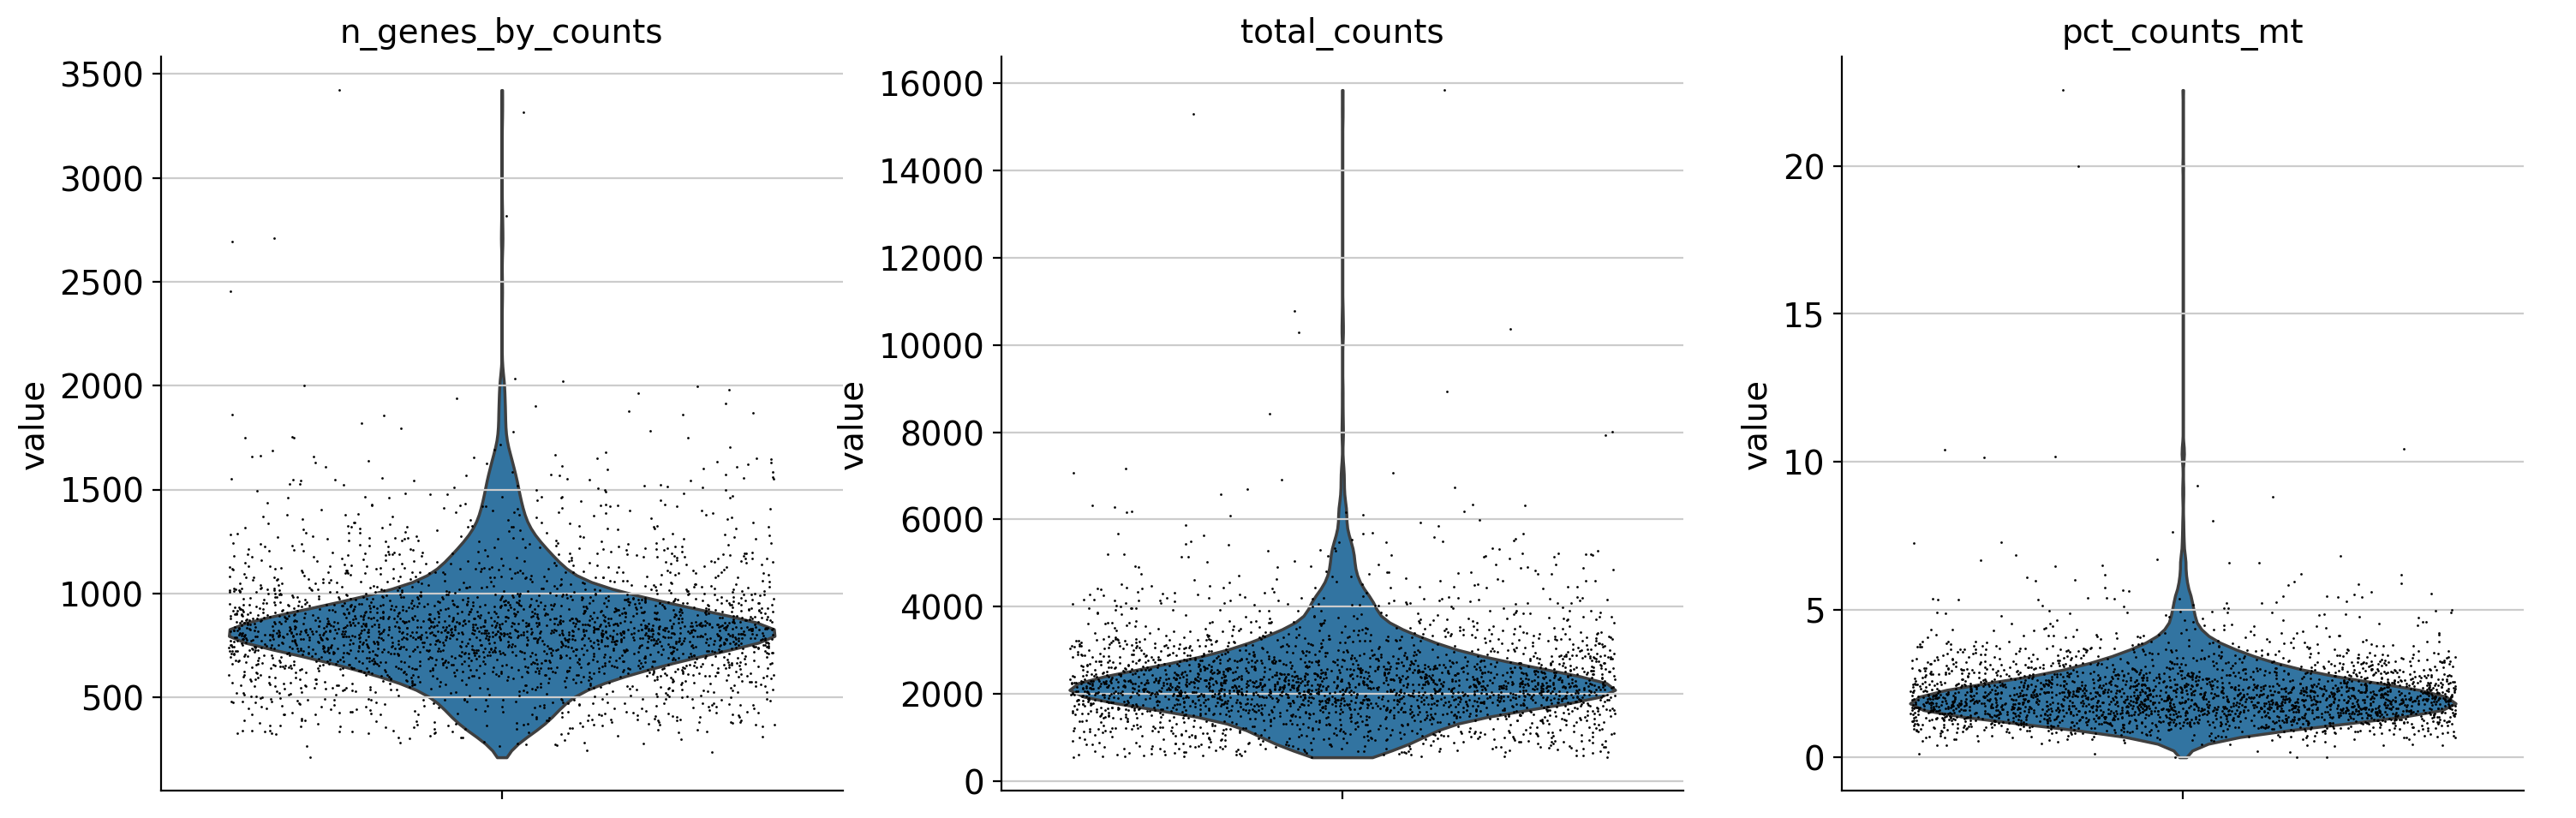

In [5]:
# Flag mitochondrial genes (they start with "MT-")
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calculate QC metrics for every cell
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

# Visualize the three key metrics
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    save="_qc_before_filtering.png"
)

In [6]:
# Filter cells
sc.pp.filter_cells(adata, min_genes=200)   # remove cells with too few genes (empty droplets)
sc.pp.filter_cells(adata, max_genes=2500)  # remove cells with too many genes (doublets)
adata = adata[adata.obs.pct_counts_mt < 5] # remove dying cells

# Filter genes
sc.pp.filter_genes(adata, min_cells=3)     # remove genes seen in fewer than 3 cells

print(f"After QC: {adata.n_obs} cells × {adata.n_vars} genes")

After QC: 2638 cells × 13656 genes


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:279: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


## 2. Normalization and Log Transformation
Normalizing library size across cells, then applying log1p
transformation to stabilize variance.

In [7]:
# Store the raw counts before any transformation — useful for DE analysis later
adata.layers["counts"] = adata.X.copy()

# Normalize: scale each cell to 10,000 total counts (CPM-style)
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform: log1p(x) = log(x + 1), avoids log(0)
sc.pp.log1p(adata)

# Store the normalized+log values as a reference layer
adata.raw = adata.copy()

print("Normalization complete.")
print(f"AnnData now contains layers: {list(adata.layers.keys())}")

Normalization complete.
AnnData now contains layers: ['counts']


### Notes:
**target_sum=1e4** scales every cell so its total counts sum to 10,000. After this, a value of 500 for gene X means "5% of this cell's RNA was gene X" — comparable across all cells.

**log1p** compresses the dynamic range. Gene counts are extremely skewed — a handful of highly expressed genes have counts in the thousands while most have counts of 0, 1, or 2. Log transformation pulls the distribution closer to normal, which makes PCA and clustering work much better.

**adata.raw = adata.copy()** saves a snapshot of the normalized data before you do the feature selection in the next step — Scanpy's differential expression functions expect to find it there.

In [9]:
!pip install scikit-misc -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 4.5 MB/s eta 0:00:00


## 3. Feature Selection — Highly Variable Genes
Selecting the most informative genes for clustering by identifying
those with the highest cell-to-cell expression variance.

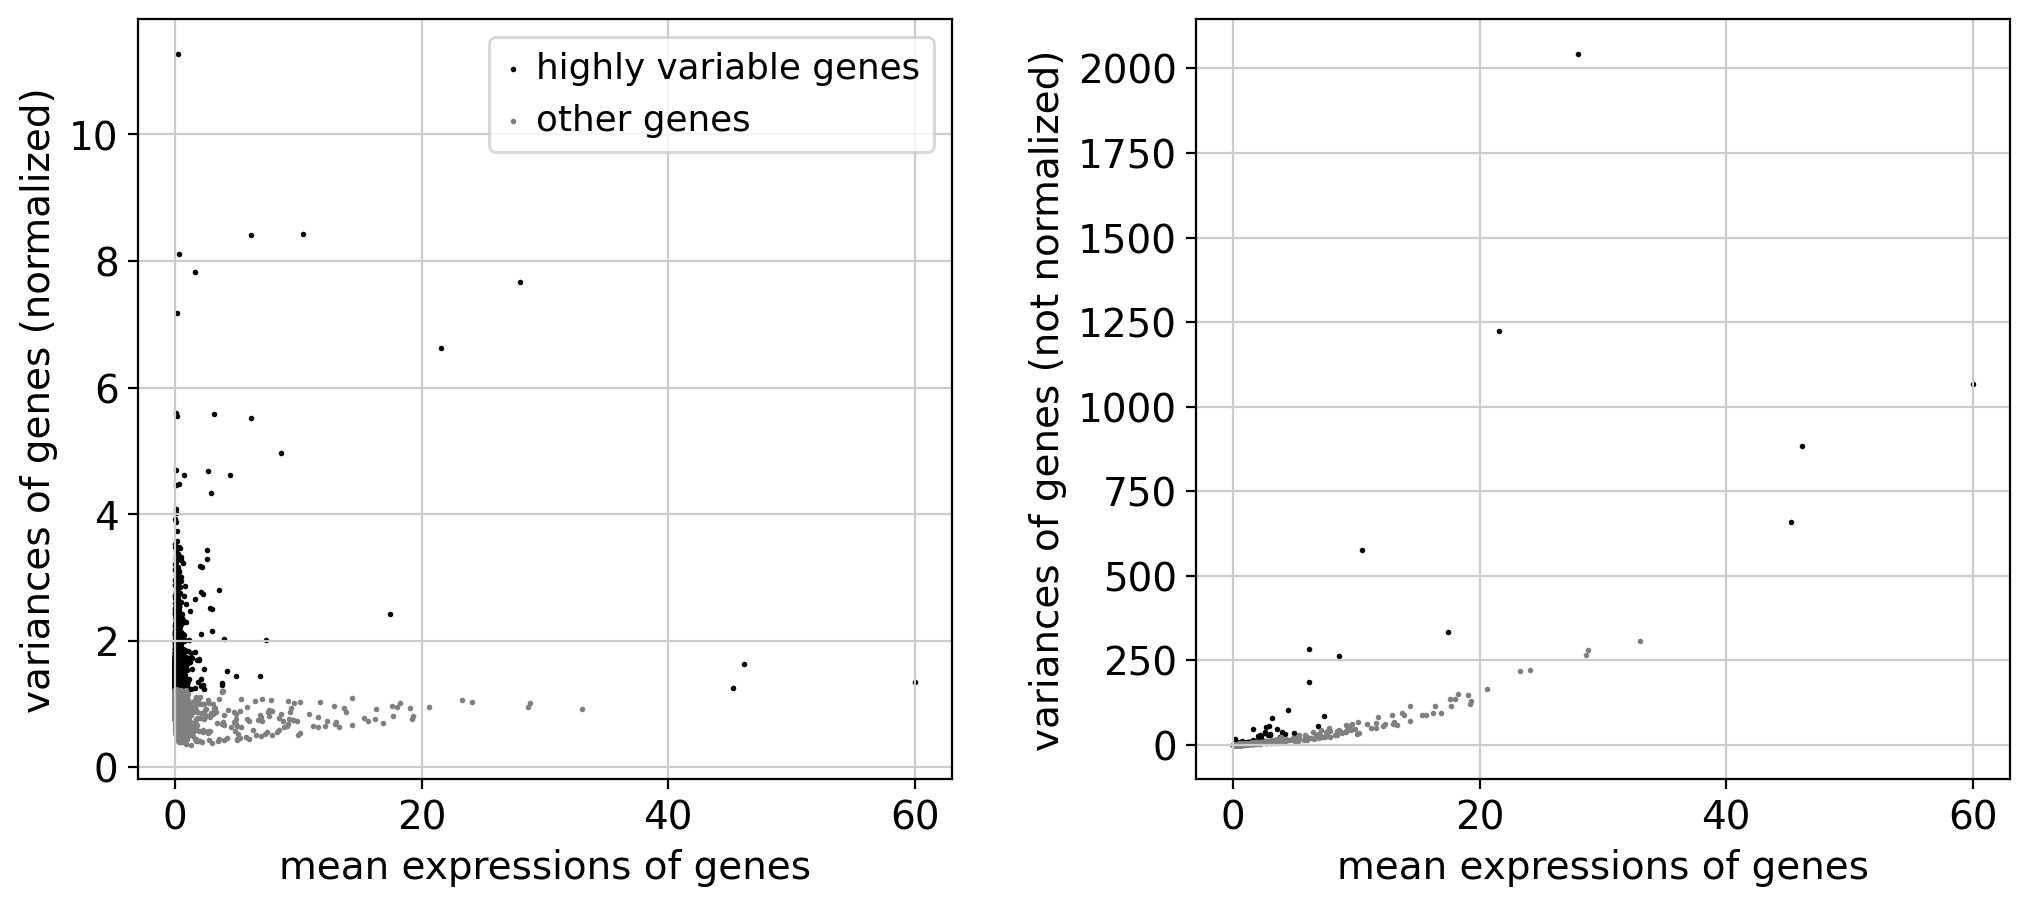

Highly variable genes selected: 2000
Total genes retained in object: 13656


In [12]:
# Identify highly variable genes
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,       # keep the 2000 most variable genes
    subset=False,           # flag them but don't remove the others yet
    layer="counts",         # compute variance on raw counts
    flavor="seurat_v3"      # industry-standard method for HVG selection
)

# Plot the variance vs. mean relationship for all genes
sc.pl.highly_variable_genes(adata)

print(f"Highly variable genes selected: {adata.var.highly_variable.sum()}")
print(f"Total genes retained in object: {adata.n_vars}")

In [13]:
# Subset to only the highly variable genes for all downstream analysis
adata = adata[:, adata.var.highly_variable]

# Regress out technical variation from total counts and mito percentage
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])

# Scale each gene to unit variance (zero mean, std=1)
# Clip extreme values at 10 standard deviations
sc.pp.scale(adata, max_value=10)

print(f"After feature selection: {adata.n_obs} cells × {adata.n_vars} genes")

/tmp/ipykernel_19374/2758712009.py:5: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:658: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:658: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


After feature selection: 2638 cells × 2000 genes


## 4. Dimensionality Reduction — PCA
Compressing 2,000 gene dimensions into 50 principal components,
capturing the major axes of cell-to-cell variation.

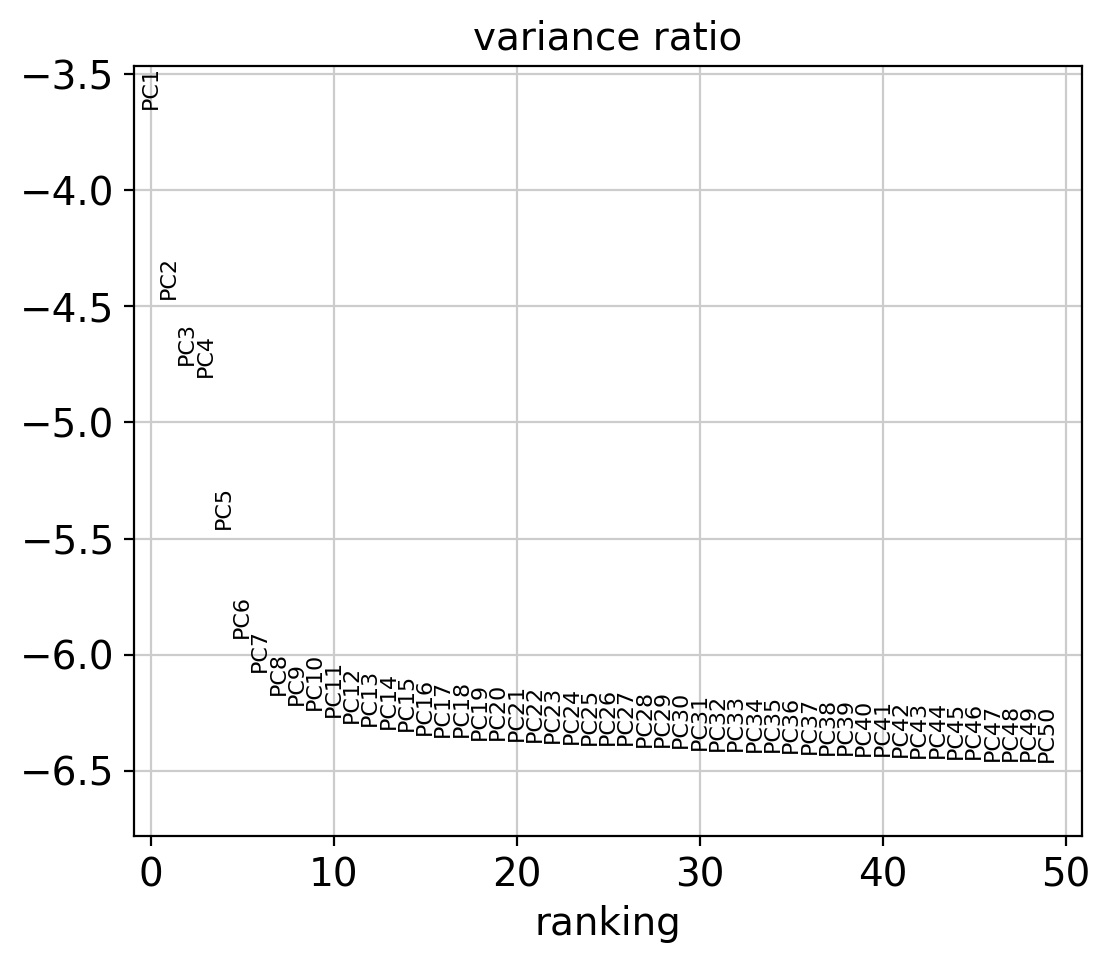

In [14]:
# Run PCA
sc.tl.pca(adata, svd_solver="arpack")

# Plot the variance explained by each PC
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

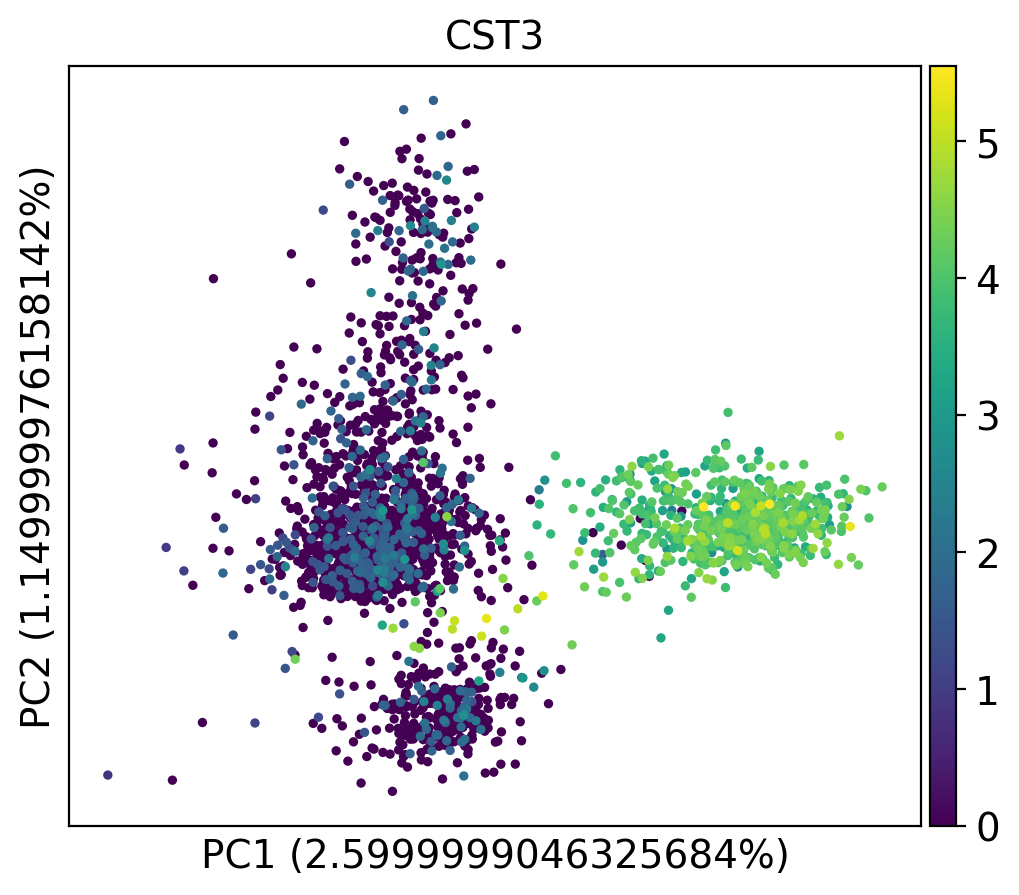

In [15]:
# Visualize cells in PCA space, colored by a QC metric
sc.pl.pca(
    adata,
    color="CST3",           # CST3 is a monocyte marker gene — should cluster visibly
    annotate_var_explained=True
)

## 5. Neighborhood Graph and UMAP
Building a k-nearest-neighbor graph in PCA space, then projecting
to 2D with UMAP for visualization.

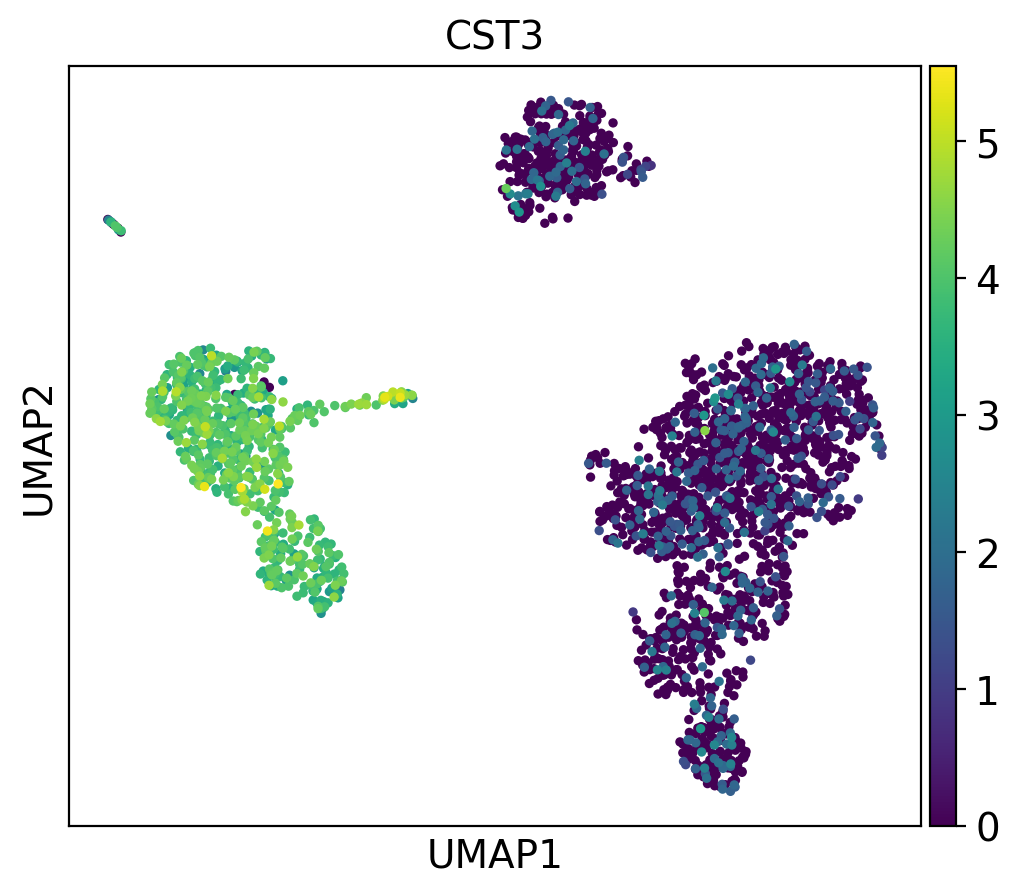

In [16]:
# Build the neighborhood graph using the first 10 PCs
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)

# Compute UMAP embedding
sc.tl.umap(adata)

# Visualize — colored by CST3 again to confirm monocytes separate cleanly
sc.pl.umap(adata, color="CST3")

## 6. Leiden Clustering
Detecting cell communities using the Leiden graph-based algorithm.
Resolution parameter controls granularity — lower values produce
fewer, broader clusters.

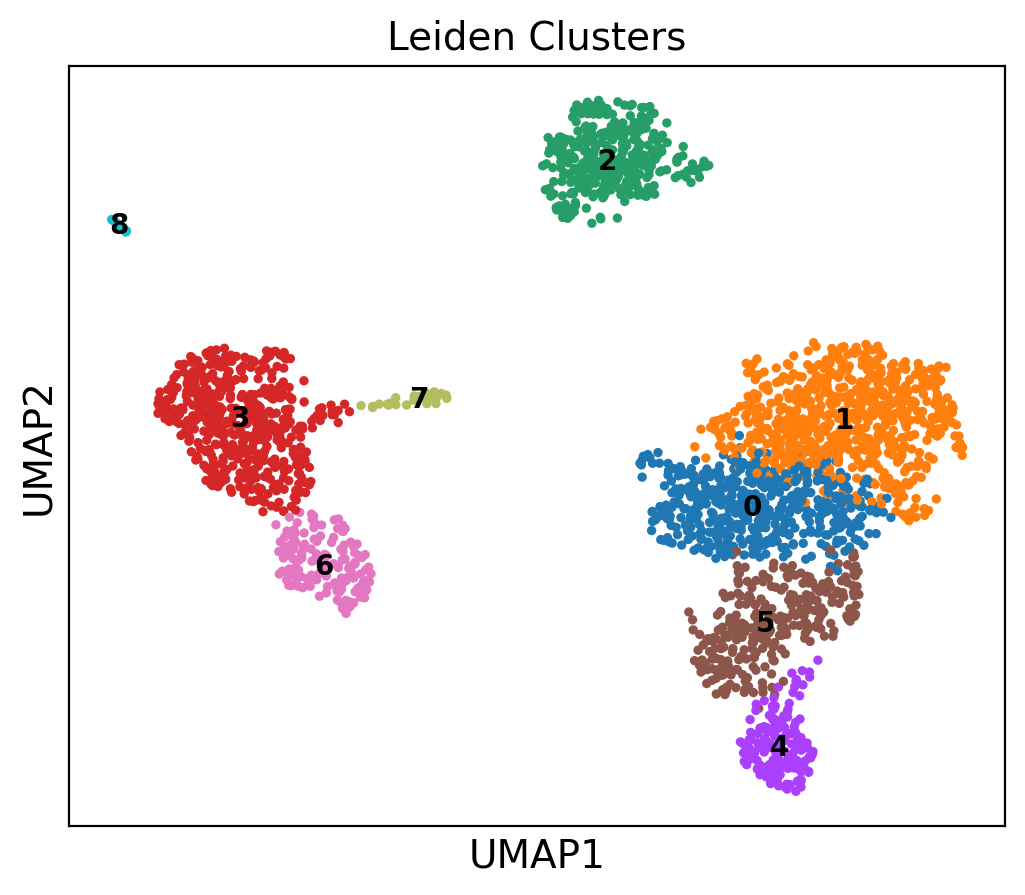

Number of clusters found: 9


In [23]:
# Run Leiden clustering
sc.tl.leiden(
    adata,
    resolution=0.5,      # lower = fewer clusters; 0.5 is a good starting point
    flavor="igraph",
    n_iterations=2,
    directed=False
)

# Visualize clusters on UMAP
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",        # cluster labels sit inside each cluster
    legend_fontsize=10,
    title="Leiden Clusters"
)

print(f"Number of clusters found: {adata.obs['leiden'].nunique()}")

## 7. Marker Gene Identification and Cell Type Annotation
Identifying genes that uniquely distinguish each cluster, then
mapping clusters to known immune cell types using canonical markers.

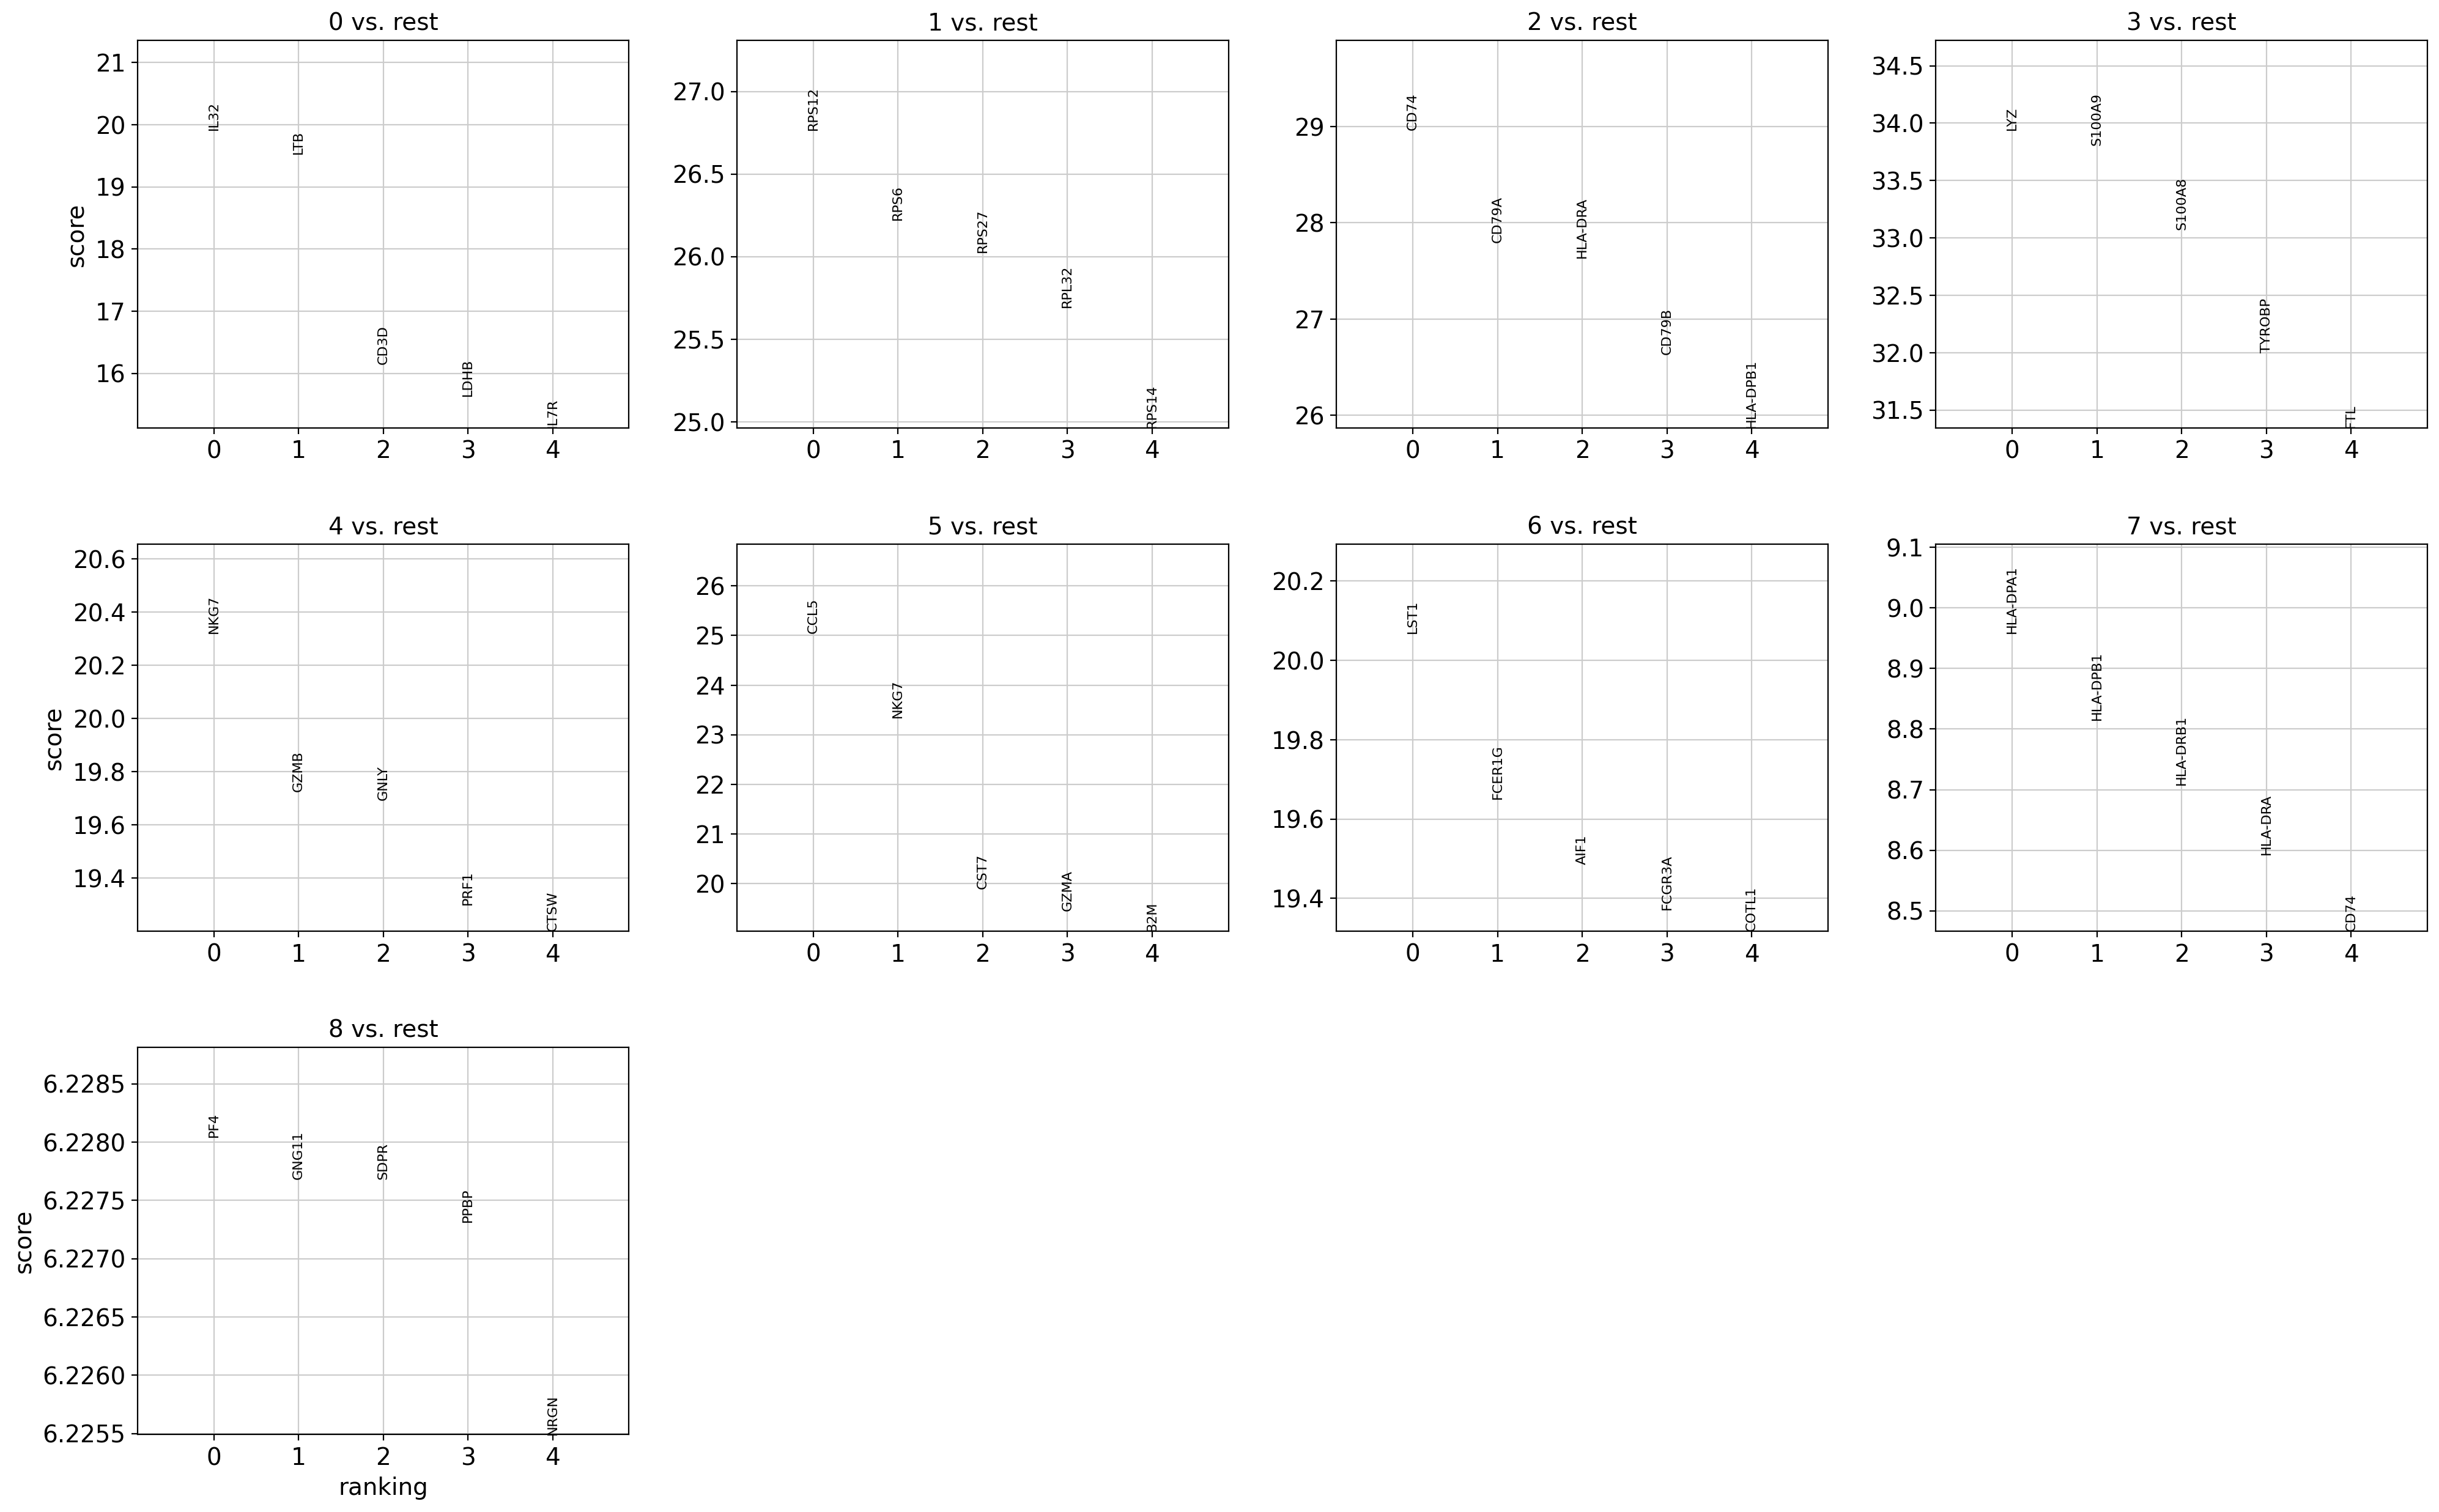

In [24]:
# Find marker genes for each cluster
# Use raw normalized counts for this (stored in adata.raw)
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",    # most robust statistical test for scRNA-seq
    use_raw=True
)

# Show the top 5 marker genes per cluster
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

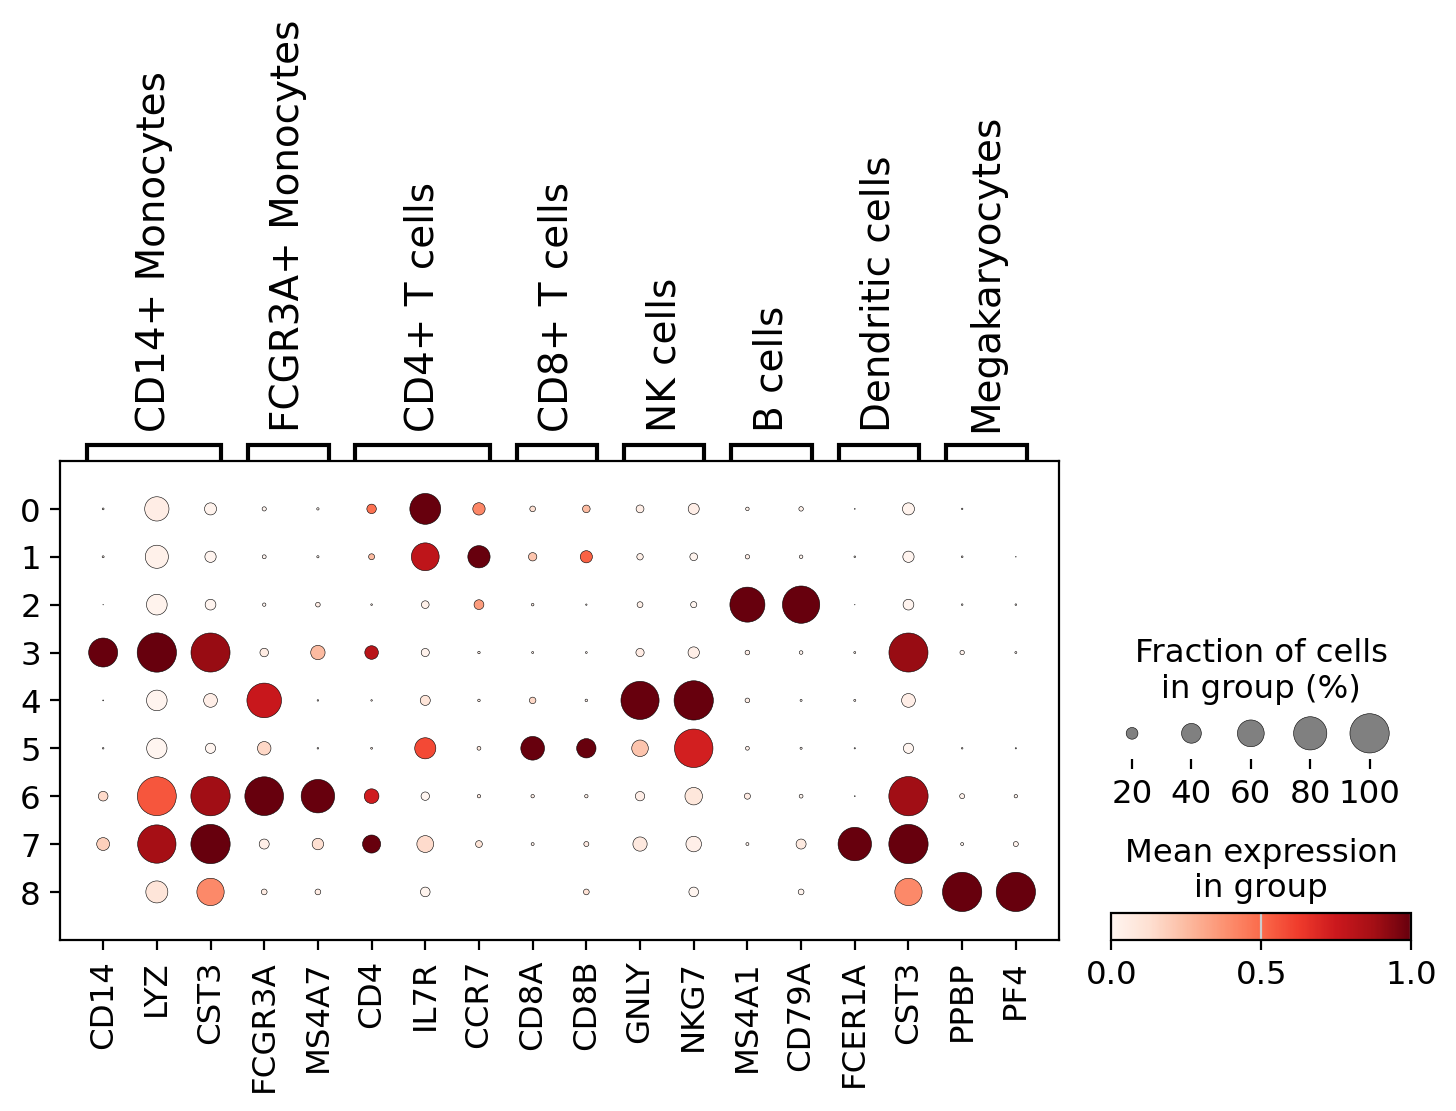

In [25]:
# Known marker genes for each PBMC cell type
marker_genes = {
    "CD14+ Monocytes":    ["CD14", "LYZ", "CST3"],
    "FCGR3A+ Monocytes":  ["FCGR3A", "MS4A7"],
    "CD4+ T cells":       ["CD4", "IL7R", "CCR7"],
    "CD8+ T cells":       ["CD8A", "CD8B"],
    "NK cells":           ["GNLY", "NKG7"],
    "B cells":            ["MS4A1", "CD79A"],
    "Dendritic cells":    ["FCER1A", "CST3"],
    "Megakaryocytes":     ["PPBP", "PF4"],
}

# Dot plot — shows expression level AND fraction of cells expressing each gene
sc.pl.dotplot(
    adata,
    marker_genes,
    groupby="leiden",
    standard_scale="var"    # normalize each gene's color scale for easier comparison
)

/tmp/ipykernel_19374/3119068635.py:18: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


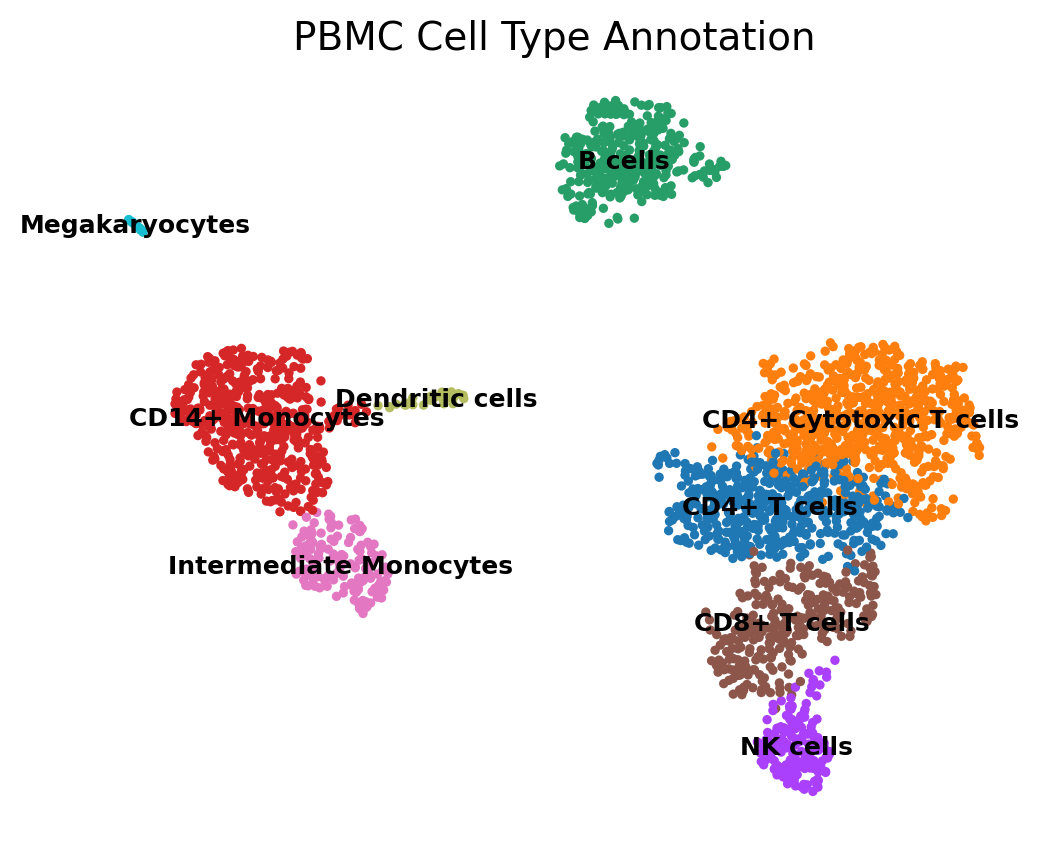

In [31]:
# Map cluster numbers to cell type names
cell_type_map = {
    "0": "CD4+ T cells",
    "1": "CD4+ Cytotoxic T cells",
    "2": "B cells",
    "3": "CD14+ Monocytes",
    "4": "NK cells",
    "5": "CD8+ T cells",
    "6": "Intermediate Monocytes",
    "7": "Dendritic cells",
    "8": "Megakaryocytes"
}

# Add annotations to the AnnData object
adata.obs["cell_type"] = adata.obs["leiden"].map(cell_type_map)

# Final annotated UMAP
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="on data",
    legend_fontsize=9,
    title="PBMC Cell Type Annotation",
    frameon=False,
    save="_cell_type_annotation.png"
)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
y = adata.obs["cell_type"].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training set: {X_train.shape[0]} cells")
print(f"Test set:     {X_test.shape[0]} cells")
print(f"Cell types:   {list(le.classes_)}")

Training set: 2110 cells
Test set:     528 cells
Cell types:   ['B cells', 'CD14+ Monocytes', 'CD4+ Cytotoxic T cells', 'CD4+ T cells', 'CD8+ T cells', 'Dendritic cells', 'Intermediate Monocytes', 'Megakaryocytes', 'NK cells']


In [34]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

                        precision    recall  f1-score   support

               B cells       1.00      0.99      0.99        69
       CD14+ Monocytes       0.90      0.98      0.94        97
CD4+ Cytotoxic T cells       0.80      0.95      0.87       139
          CD4+ T cells       0.87      0.62      0.72        95
          CD8+ T cells       0.92      0.97      0.94        58
       Dendritic cells       1.00      0.83      0.91         6
Intermediate Monocytes       0.92      0.71      0.80        31
        Megakaryocytes       1.00      1.00      1.00         2
              NK cells       1.00      0.94      0.97        31

              accuracy                           0.89       528
             macro avg       0.93      0.89      0.90       528
          weighted avg       0.89      0.89      0.88       528



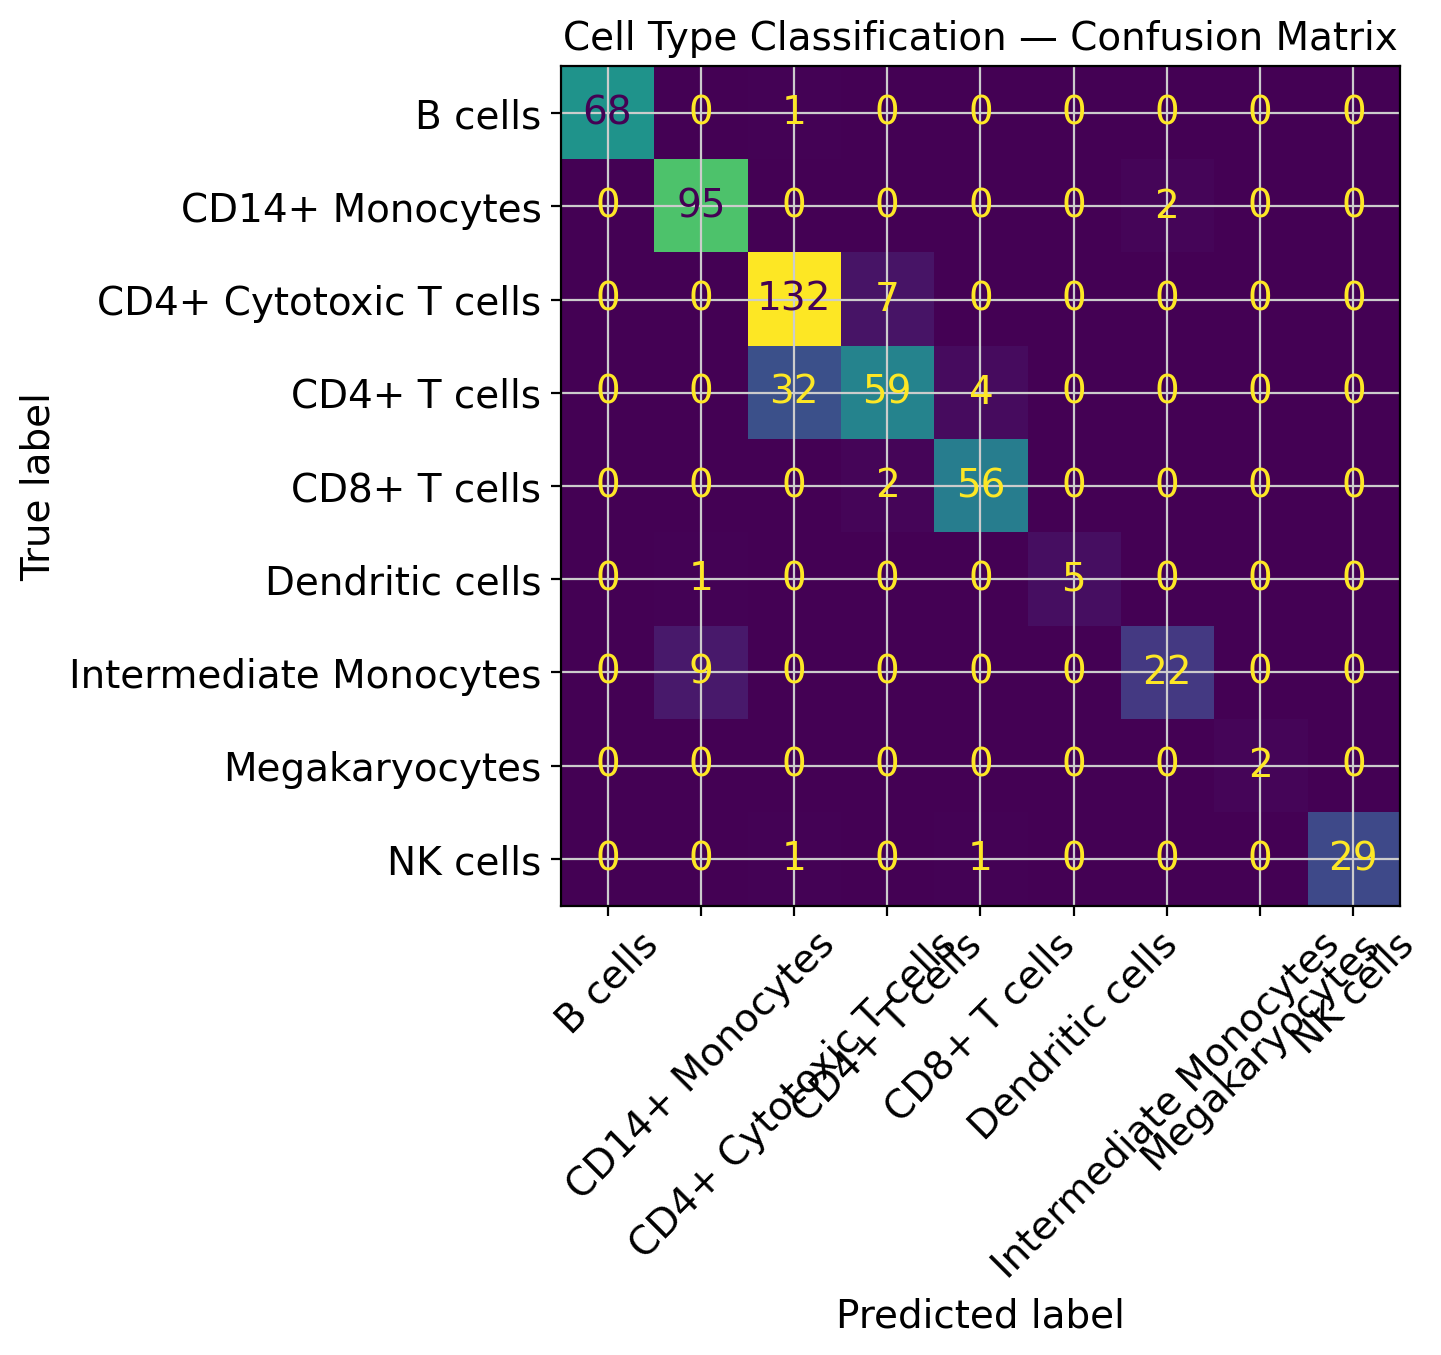

In [35]:
fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    ax=ax,
    colorbar=False,
    xticks_rotation=45
)

ax.set_title("Cell Type Classification — Confusion Matrix")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

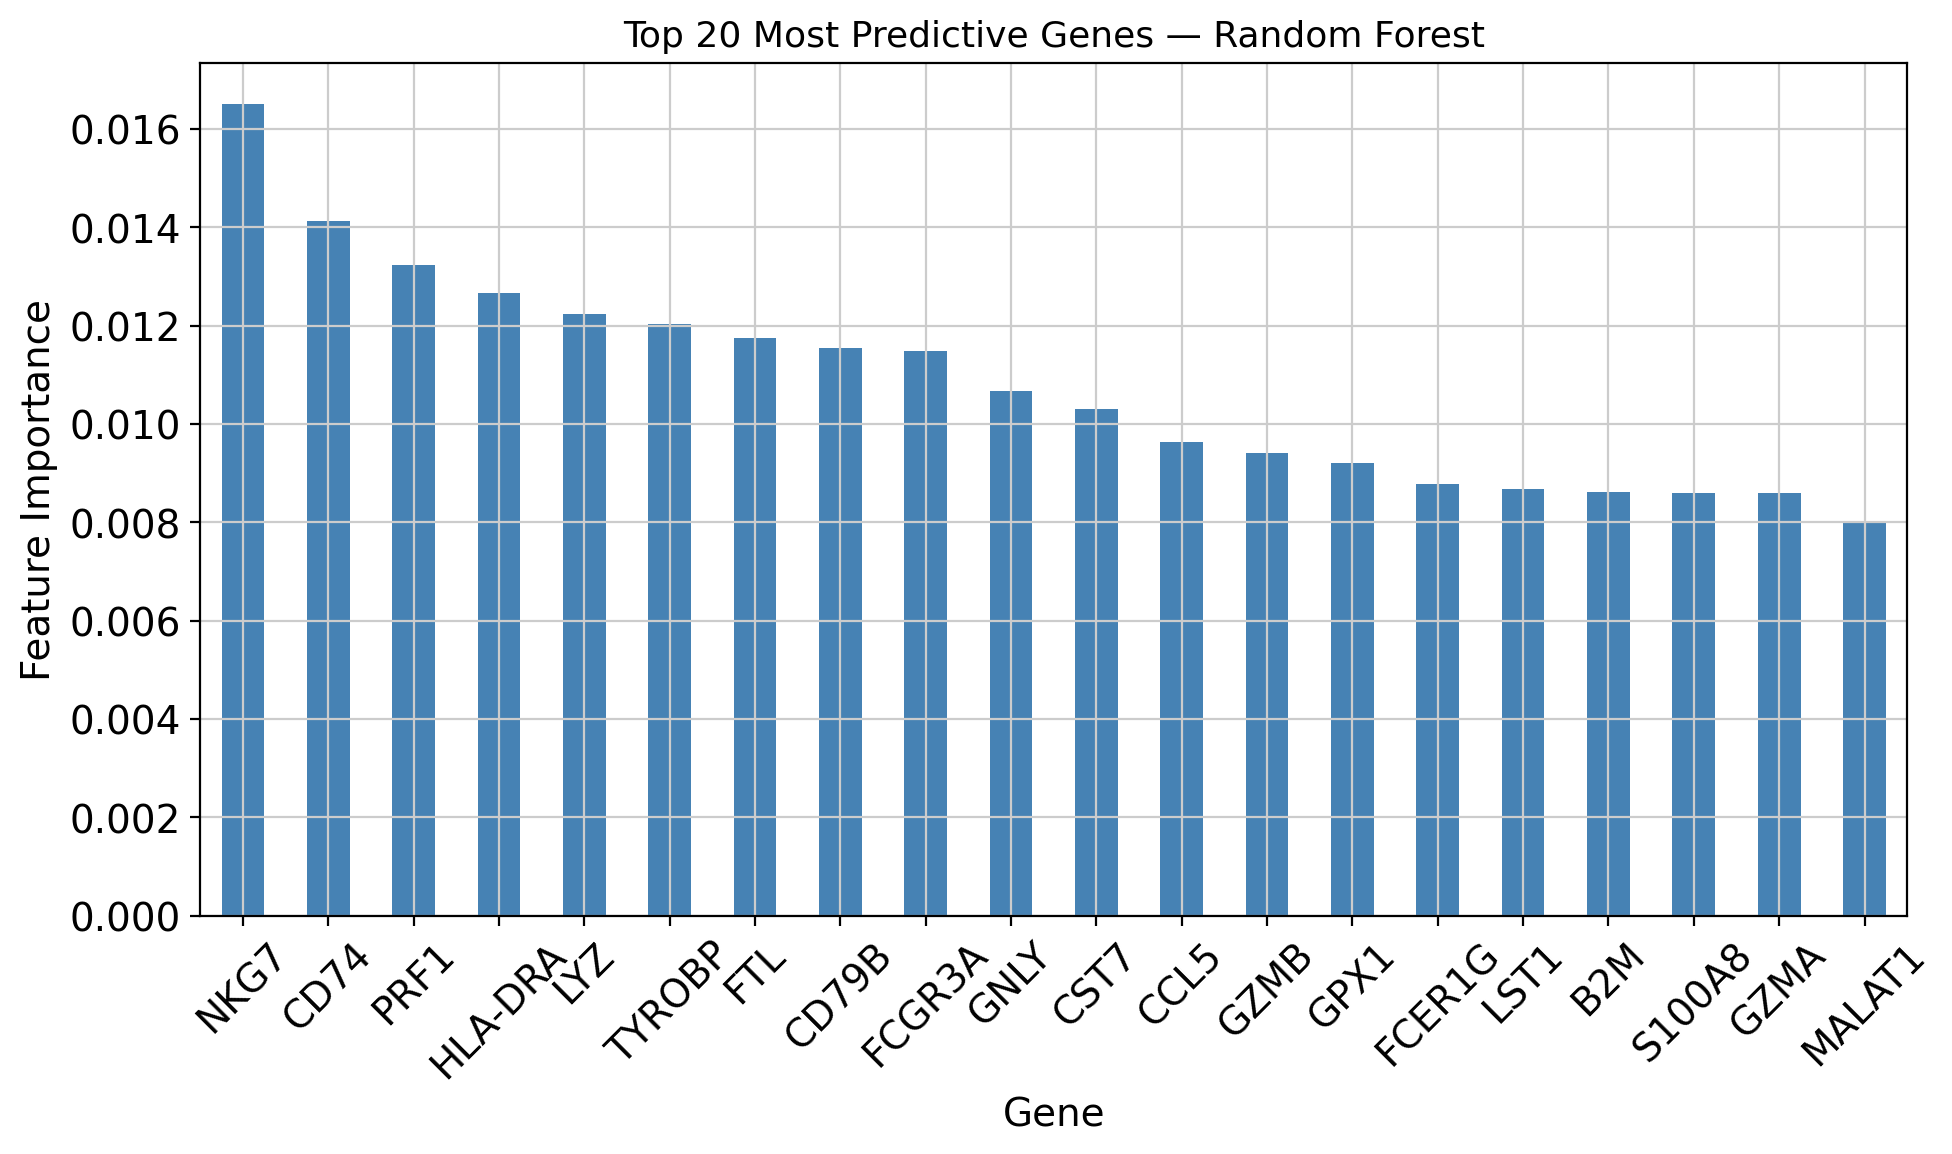

Top 10 most predictive genes:
NKG7       0.016519
CD74       0.014125
PRF1       0.013238
HLA-DRA    0.012659
LYZ        0.012239
TYROBP     0.012033
FTL        0.011743
CD79B      0.011539
FCGR3A     0.011491
GNLY       0.010676
dtype: float64


In [36]:
# Get feature importances from the trained Random Forest
feature_importances = pd.Series(
    rf.feature_importances_,
    index=adata.var_names
).sort_values(ascending=False)

# Plot top 20 most important genes
fig, ax = plt.subplots(figsize=(10, 6))

feature_importances.head(20).plot(
    kind="bar",
    ax=ax,
    color="steelblue",
    edgecolor="none"
)

ax.set_title("Top 20 Most Predictive Genes — Random Forest", fontsize=13)
ax.set_xlabel("Gene")
ax.set_ylabel("Feature Importance")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 most predictive genes:")
print(feature_importances.head(10))

## Summary
This analysis identified 9 distinct immune cell populations from 2,638 PBMCs
using an end-to-end scRNA-seq pipeline. A Random Forest classifier trained on
2,000 highly variable genes achieved 89% accuracy and 0.90 macro F1-score across
all cell types. All misclassifications occurred at known biological boundaries
(e.g. CD4+ T cell subsets, intermediate monocytes), indicating the model captured
genuine transcriptional structure rather than noise.